# Name = TAKSH SAMIRKUMAR PATEL
# Minor_Project = Estimate the BMI based on the Gender, Height & Weight.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import os

In [5]:
project_path = os.getcwd()
file_path = project_path + '/weight-height.csv'
df = pd.read_csv(file_path)
df

,Height,Weight,Gender,Age,BMI,Weight_Category,Activity_Level,Systolic_BP,Diastolic_BP,BP_Category,Cholesterol,Cholesterol_Category,Smoker
0,161.72,53.80,Female,19,20.57,Normal,Sedentary,140,90,High,150,Normal,No
1,171.99,76.12,Male,56,25.73,Overweight,Lightly Active,122,73,Elevated,192,Normal,No
2,179.51,87.38,Male,69,27.12,Overweight,Sedentary,126,97,High,231,Borderline,No
3,179.68,74.28,Male,20,23.01,Normal,Very Active,102,71,Normal,235,Borderline,No
4,162.94,62.76,Female,54,23.64,Normal,Lightly Active,126,60,Elevated,249,High,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,179.01,70.00,Male,47,21.84,Normal,Moderately Active,100,81,Elevated,254,High,No
49996,165.44,65.99,Male,37,24.11,Normal,Lightly Active,90,93,High,211,Borderline,No
49997,182.62,82.04,Male,49,24.60,Normal,Lightly Active,106,87,Elevated,200,Borderline,No
49998,158.26,54.17,Female,65,21.63,Normal,Lightly Active,149,79,High,202,Borderline,No


# BASIC EDA

In [6]:
df.head()

,Height,Weight,Gender,Age,BMI,Weight_Category,Activity_Level,Systolic_BP,Diastolic_BP,BP_Category,Cholesterol,Cholesterol_Category,Smoker
0,161.72,53.80,Female,19,20.57,Normal,Sedentary,140,90,High,150,Normal,No
1,171.99,76.12,Male,56,25.73,Overweight,Lightly Active,122,73,Elevated,192,Normal,No
2,179.51,87.38,Male,69,27.12,Overweight,Sedentary,126,97,High,231,Borderline,No
3,179.68,74.28,Male,20,23.01,Normal,Very Active,102,71,Normal,235,Borderline,No
4,162.94,62.76,Female,54,23.64,Normal,Lightly Active,126,60,Elevated,249,High,No


In [7]:
df.tail()

,Height,Weight,Gender,Age,BMI,Weight_Category,Activity_Level,Systolic_BP,Diastolic_BP,BP_Category,Cholesterol,Cholesterol_Category,Smoker
49995,179.01,70.00,Male,47,21.84,Normal,Moderately Active,100,81,Elevated,254,High,No
49996,165.44,65.99,Male,37,24.11,Normal,Lightly Active,90,93,High,211,Borderline,No
49997,182.62,82.04,Male,49,24.60,Normal,Lightly Active,106,87,Elevated,200,Borderline,No
49998,158.26,54.17,Female,65,21.63,Normal,Lightly Active,149,79,High,202,Borderline,No
49999,177.80,61.83,Male,33,19.56,Normal,Sedentary,139,72,Elevated,150,Normal,No


In [9]:
df.shape

(50000, 13)

In [11]:
df.columns

Index(['Height', 'Weight', 'Gender', 'Age', 'BMI', 'Weight_Category',
       'Activity_Level', 'Systolic_BP', 'Diastolic_BP', 'BP_Category',
       'Cholesterol', 'Cholesterol_Category', 'Smoker'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Height                50000 non-null  float64
 1   Weight                50000 non-null  float64
 2   Gender                50000 non-null  object 
 3   Age                   50000 non-null  int64  
 4   BMI                   50000 non-null  float64
 5   Weight_Category       50000 non-null  object 
 6   Activity_Level        50000 non-null  object 
 7   Systolic_BP           50000 non-null  int64  
 8   Diastolic_BP          50000 non-null  int64  
 9   BP_Category           50000 non-null  object 
 10  Cholesterol           50000 non-null  int64  
 11  Cholesterol_Category  50000 non-null  object 
 12  Smoker                50000 non-null  object 
dtypes: float64(3), int64(4), object(6)
memory usage: 5.0+ MB


In [13]:
df.describe

<bound method NDFrame.describe of        Height  Weight  Gender  Age    BMI Weight_Category     Activity_Level  \
0      161.72   53.80  Female   19  20.57          Normal          Sedentary   
1      171.99   76.12    Male   56  25.73      Overweight     Lightly Active   
2      179.51   87.38    Male   69  27.12      Overweight          Sedentary   
3      179.68   74.28    Male   20  23.01          Normal        Very Active   
4      162.94   62.76  Female   54  23.64          Normal     Lightly Active   
...       ...     ...     ...  ...    ...             ...                ...   
49995  179.01   70.00    Male   47  21.84          Normal  Moderately Active   
49996  165.44   65.99    Male   37  24.11          Normal     Lightly Active   
49997  182.62   82.04    Male   49  24.60          Normal     Lightly Active   
49998  158.26   54.17  Female   65  21.63          Normal     Lightly Active   
49999  177.80   61.83    Male   33  19.56          Normal          Sedentary   

     

In [14]:
df.isnull()

,Height,Weight,Gender,Age,BMI,Weight_Category,Activity_Level,Systolic_BP,Diastolic_BP,BP_Category,Cholesterol,Cholesterol_Category,Smoker
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,False,False,False,False,False,False,False,False,False,False,False,False,False
49996,False,False,False,False,False,False,False,False,False,False,False,False,False
49997,False,False,False,False,False,False,False,False,False,False,False,False,False
49998,False,False,False,False,False,False,False,False,False,False,False,False,False


In [15]:
df.isnull().sum()

Height                  0
Weight                  0
Gender                  0
Age                     0
BMI                     0
Weight_Category         0
Activity_Level          0
Systolic_BP             0
Diastolic_BP            0
BP_Category             0
Cholesterol             0
Cholesterol_Category    0
Smoker                  0
dtype: int64

In [16]:
df = df[['Height','Weight','Gender','BMI']]
df

,Height,Weight,Gender,BMI
0,161.72,53.80,Female,20.57
1,171.99,76.12,Male,25.73
2,179.51,87.38,Male,27.12
3,179.68,74.28,Male,23.01
4,162.94,62.76,Female,23.64
...,...,...,...,...
49995,179.01,70.00,Male,21.84
49996,165.44,65.99,Male,24.11
49997,182.62,82.04,Male,24.60
49998,158.26,54.17,Female,21.63


In [17]:
df['Gender']

0        Female
1          Male
2          Male
3          Male
4        Female
          ...  
49995      Male
49996      Male
49997      Male
49998    Female
49999      Male
Name: Gender, Length: 50000, dtype: object

In [19]:
le_en = LabelEncoder()
df['Gender'] = le_en.fit_transform(df['Gender'])
df['Gender']

C:\Users\Taksh\AppData\Local\Temp\ipykernel_18936\2094992678.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = le_en.fit_transform(df['Gender'])


0        0
1        1
2        1
3        1
4        0
        ..
49995    1
49996    1
49997    1
49998    0
49999    1
Name: Gender, Length: 50000, dtype: int64

# Build Train and Test data

In [21]:
X = df[['Height','Weight','Gender']]
Y = df['BMI']

In [22]:
X

,Height,Weight,Gender
0,161.72,53.80,0
1,171.99,76.12,1
2,179.51,87.38,1
3,179.68,74.28,1
4,162.94,62.76,0
...,...,...,...
49995,179.01,70.00,1
49996,165.44,65.99,1
49997,182.62,82.04,1
49998,158.26,54.17,0


In [23]:
Y

0        20.57
1        25.73
2        27.12
3        23.01
4        23.64
         ...  
49995    21.84
49996    24.11
49997    24.60
49998    21.63
49999    19.56
Name: BMI, Length: 50000, dtype: float64

In [24]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state=42)

# Model Building

In [26]:
lr = LinearRegression()
lr.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
X_train

,Height,Weight,Gender
39087,166.69,69.97,1
30893,184.63,86.51,1
45278,169.17,69.69,1
16398,152.01,48.92,0
13653,178.07,77.13,1
...,...,...,...
11284,155.10,56.78,0
44732,173.55,75.88,1
38158,159.13,51.24,0
860,168.57,64.93,1


In [28]:
X_test

,Height,Weight,Gender
33553,175.69,67.17,1
9427,181.25,83.90,1
199,179.29,65.46,0
12447,174.47,59.56,1
39489,177.21,81.66,1
...,...,...,...
28567,184.04,95.27,1
25079,189.27,90.42,1
18707,164.11,65.73,1
15200,165.90,58.59,1


In [29]:
Y_train

39087    25.18
30893    25.38
45278    24.35
16398    21.17
13653    24.32
         ...  
11284    23.60
44732    25.19
38158    20.24
860      22.85
15795    23.95
Name: BMI, Length: 40000, dtype: float64

In [30]:
Y_test

33553    21.76
9427     25.54
199      20.36
12447    19.57
39489    26.00
         ...  
28567    28.13
25079    25.24
18707    24.41
15200    21.29
5857     25.04
Name: BMI, Length: 10000, dtype: float64

In [32]:
Y_pred = lr.predict(X_test)

In [35]:
print("Mean Squared Error:", mean_squared_error(Y_test, Y_pred))
print("R2 Score:", r2_score(Y_test, Y_pred))

Mean Squared Error: 0.08368023025507848
R2 Score: 0.9839082174823714


# Graph

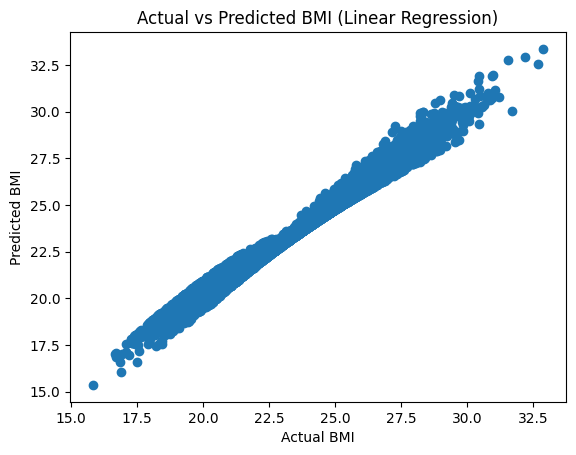

In [37]:
plt.figure()
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Actual vs Predicted BMI (Linear Regression)")
plt.show()

# Model Prediction

In [43]:
gender = "Male"
height = 171.99					
weight = 76.12

# Encode gender
gender_encoded = le_en.transform([gender])[0]

# Predict BMI
predicted_bmi = lr.predict([[ height, weight,gender_encoded]])

print("Predicted BMI:", predicted_bmi[0])

Predicted BMI: 25.67704497782636


C:\Users\Taksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# ------------------------------------ END------------------------------------------